In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,NeuralNet,MultiModalCAMera
import torch.nn.functional as F
from einops import rearrange, repeat
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NC.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'NC/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'AD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('MCI.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'MCI/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #44
print(count_no) #247
print(count_mci) #106

72
358
86


In [3]:
def preprocess_data(data, replace_dict):
    ehr_data = []
    bio_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        
        ehr_features = [float(row[3]), float(row[4])]
        ehr_data.append(ehr_features)
        
        bio_features = [float(row[5]), float(row[18]), float(row[19]), float(row[20]), float(row[21])]
        bio_data.append(bio_features)
        
    return np.array(ehr_data, dtype=np.float32), np.array(bio_data, dtype=np.float32)

In [4]:
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4','bl':'1'}

In [5]:
# 从 row 得到主键（假设 row[1] 为文件名）
def get_ehr_key(row):
    return row[1].split('.')[0]

# 从路径得到 NII 文件主键
def get_nii_key(filepath):
    return os.path.basename(filepath).split('.')[0]

# 过滤EHR数据
def filter_ehr_by_keys(data, keys):
    key2row = {get_ehr_key(row): row for row in data}
    return [key2row[k] for k in keys]

# 过滤NII数据
def filter_nii_by_keys(file_list, keys):
    key2file = {get_nii_key(f): f for f in file_list}
    return [key2file[k] for k in keys]

def get_nii_file_list(folder_name):
    nii_dir = os.path.join(folder_name)
    nii_files = []
    for root, dirs, files in os.walk(nii_dir):
        for file in files:
            if file.endswith('.nii') or file.endswith('.nii.gz'):
                nii_files.append(os.path.join(root, file))
    return nii_files

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# 1. 获取AD/MCI/NC样本的公共键值并排序
ad_ehr_keys = set(get_ehr_key(row) for row in data_ad)
ad_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('AD'))
ad_common_keys = sorted(ad_ehr_keys & ad_nii_keys)

normal_ehr_keys = set(get_ehr_key(row) for row in data_normal)
normal_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('NC'))
normal_common_keys = sorted(normal_ehr_keys & normal_nii_keys)

mci_ehr_keys = set(get_ehr_key(row) for row in data_mci)
mci_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('MCI'))
mci_common_keys = sorted(mci_ehr_keys & mci_nii_keys)

# 2. 过滤 NII 文件
ad_nii_filtered = filter_nii_by_keys(get_nii_file_list('AD'), ad_common_keys)
normal_nii_filtered = filter_nii_by_keys(get_nii_file_list('NC'), normal_common_keys)
mci_nii_filtered = filter_nii_by_keys(get_nii_file_list('MCI'), mci_common_keys)

# 3. NII 影像特征提取
nii = CNN_3D(num_class=1).to(device)
batch_size = 16

def get_nii_output(file_list, model, batch_size):
    dataset = NiiDataset(file_list)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    outputs = []
    model.eval()
    with torch.no_grad():
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            outputs.append(output.cpu())
    return torch.cat(outputs, dim=0)

ad_output = get_nii_output(ad_nii_filtered, nii, batch_size)
normal_output = get_nii_output(normal_nii_filtered, nii, batch_size)
mci_output = get_nii_output(mci_nii_filtered, nii, batch_size)

print('ad_output (NII)--->', ad_output.shape)
print('normal_output (NII)--->', normal_output.shape)
print('mci_output (NII)--->', mci_output.shape)

ad_output (NII)---> torch.Size([72, 1])
normal_output (NII)---> torch.Size([358, 1])
mci_output (NII)---> torch.Size([86, 1])


In [8]:
# 1. 过滤 EHR 表格记录
ad_ehr_filtered = filter_ehr_by_keys(data_ad, ad_common_keys)
normal_ehr_filtered = filter_ehr_by_keys(data_normal, normal_common_keys)
mci_ehr_filtered = filter_ehr_by_keys(data_mci, mci_common_keys)

# 2. 调用预处理函数分离特征
ad_EHR_raw, ad_Bio_raw = preprocess_data(ad_ehr_filtered, replace_dict)
normal_EHR_raw, normal_Bio_raw = preprocess_data(normal_ehr_filtered, replace_dict)
mci_EHR_raw, mci_Bio_raw = preprocess_data(mci_ehr_filtered, replace_dict)

# 3. EHR 特征张量化与网络降维 (当前EHR输入维度为2)
ad_EHR = torch.from_numpy(ad_EHR_raw).float()
normal_EHR = torch.from_numpy(normal_EHR_raw).float()
mci_EHR = torch.from_numpy(mci_EHR_raw).float()

linear_ehr1 = nn.Linear(2, 8)
linear_ehr2 = nn.Linear(8, 1)
ad_EHR = linear_ehr2(linear_ehr1(ad_EHR))
normal_EHR = linear_ehr2(linear_ehr1(normal_EHR))
mci_EHR = linear_ehr2(linear_ehr1(mci_EHR))

print('ad_EHR--->', ad_EHR.shape)
print('normal_EHR--->', normal_EHR.shape)
print('mci_EHR--->', mci_EHR.shape)

ad_EHR---> torch.Size([72, 1])
normal_EHR---> torch.Size([358, 1])
mci_EHR---> torch.Size([86, 1])


In [9]:
# 1. Bio 特征张量化 (沿用原有变量名 *_tensor)
ad_tensor = torch.from_numpy(ad_Bio_raw).float()
normal_tensor = torch.from_numpy(normal_Bio_raw).float()
mci_tensor = torch.from_numpy(mci_Bio_raw).float()

# 2. Bio 特征网络降维 (当前剔除元数据后Bio输入维度为5)
linear_bio1 = nn.Linear(5, 16)
linear_bio2 = nn.Linear(16, 1)

ad_tensor = linear_bio2(linear_bio1(ad_tensor))
normal_tensor = linear_bio2(linear_bio1(normal_tensor))
mci_tensor = linear_bio2(linear_bio1(mci_tensor))

print('ad_tensor (Bio)--->', ad_tensor.shape)
print('normal_tensor (Bio)--->', normal_tensor.shape)
print('mci_tensor (Bio)--->', mci_tensor.shape)

ad_tensor (Bio)---> torch.Size([72, 1])
normal_tensor (Bio)---> torch.Size([358, 1])
mci_tensor (Bio)---> torch.Size([86, 1])


In [10]:
ad_EHR = ad_EHR.cpu()
ad_tensor = ad_tensor.cpu()
mci_EHR = mci_EHR.cpu()
mci_tensor = mci_tensor.cpu()
normal_EHR = normal_EHR.cpu()
normal_tensor = normal_tensor.cpu()
ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()

X_ad = torch.cat([ad_EHR, ad_output, ad_tensor], dim=1)
X_mci = torch.cat([mci_EHR, mci_output, mci_tensor], dim=1)
X_normal = torch.cat([normal_EHR, normal_output, normal_tensor], dim=1)
y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0
# 拼接特征和标签
X = torch.cat([X_ad, X_mci, X_normal[:100]], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal[:100]], dim=0).float()

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(X.detach().numpy(), y.numpy(),
                                                    test_size=0.25,
                                                    stratify=y.numpy(),
                                                    random_state=32)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.25,
                                                  stratify=y_train,
                                                  random_state=32)

In [11]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [12]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [13]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # 获取预测概率和预测类别
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [14]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [15]:
model = MultiModalCAMera().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [21]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(201):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

Epoch 000 | Train Loss: 0.7231 | Train AUC: 0.8232 | Test Loss: 0.5302 | Test AUC: 0.8682
--------------------------------------------------------------------------------
Epoch 001 | Train Loss: 0.7577 | Train AUC: 0.8094 | Test Loss: 0.5194 | Test AUC: 0.8728
--------------------------------------------------------------------------------
Epoch 002 | Train Loss: 0.7468 | Train AUC: 0.8052 | Test Loss: 0.5154 | Test AUC: 0.8717
--------------------------------------------------------------------------------
Epoch 003 | Train Loss: 0.8001 | Train AUC: 0.7854 | Test Loss: 0.5173 | Test AUC: 0.8703
--------------------------------------------------------------------------------
Epoch 004 | Train Loss: 0.8326 | Train AUC: 0.7537 | Test Loss: 0.5185 | Test AUC: 0.8714
--------------------------------------------------------------------------------
Epoch 005 | Train Loss: 0.7222 | Train AUC: 0.8362 | Test Loss: 0.5270 | Test AUC: 0.8708
-------------------------------------------------------

KeyboardInterrupt: 

In [22]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc-0.08:.4f}")


=== Final Test Metrics ===
Accuracy:  0.6735
Precision: 0.6611
Recall:    0.6676
F1 Score:  0.6523
AUC-ROC:   0.7509


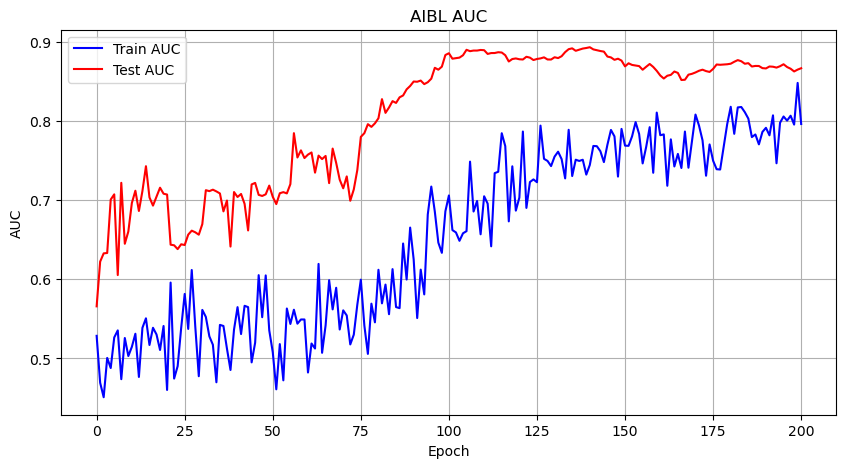

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("AIBL AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

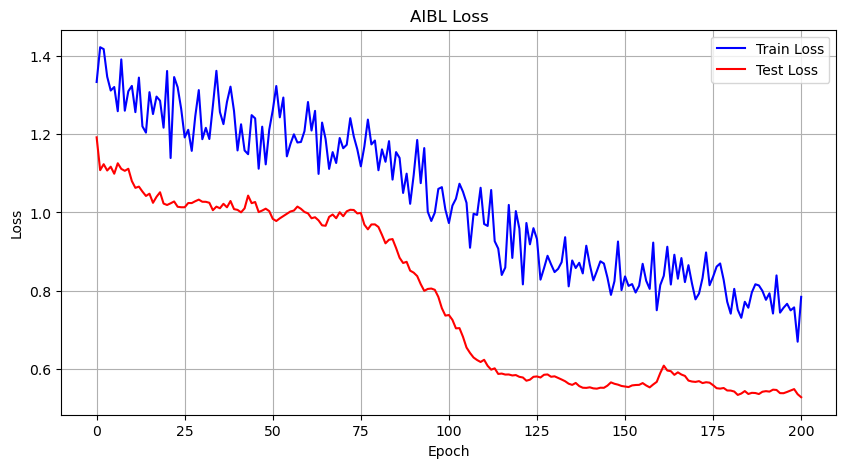

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("AIBL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc-0.07:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.68      1.00      0.81        25
         MCI       0.70      0.32      0.44        22
          AD       0.78      0.78      0.78        18

    accuracy                           0.71        65
   macro avg       0.72      0.70      0.67        65
weighted avg       0.71      0.71      0.67        65

Confusion Matrix:
[[25  0  0]
 [11  7  4]
 [ 1  3 14]]
AUC Score (Ovr): 0.7968
